In [43]:
# Library import

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [44]:
# Load merged dataset
df = pd.read_csv('../data/tracks_clean.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (586672, 23)
Columns: ['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'main_artist', 'id_main_artist', 'year']


In [45]:
# Check for missing values in duration_ms and release_date columns
print(f"Missing values in 'duration_ms': {df['duration_ms'].isna().sum()}")
print(f"Missing values in 'release_date': {df['release_date'].isna().sum()}")

# Remove rows with missing values
df_clean = df.dropna(subset=['duration_ms', 'release_date']).copy()
print(f"Dataset shape after cleaning: {df_clean.shape}")

# Convert duration from milliseconds to minutes for better interpretation
df_clean['duration_minutes'] = df_clean['duration_ms'] / 1000 / 60

# Convert release_date to datetime
# (tracks_clean.csv can contain partial dates; coerce invalid parses to NaT)
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# Prefer the existing 'year' column if present; otherwise extract from release_date
if 'year' in df_clean.columns:
    df_clean['release_year'] = pd.to_numeric(df_clean['year'], errors='coerce')
else:
    df_clean['release_year'] = df_clean['release_date'].dt.year

# Filter out invalid years
df_clean = df_clean.dropna(subset=['release_year'])
df_clean = df_clean[(df_clean['release_year'] >= 1900) & (df_clean['release_year'] <= 2030)]

print(f"Dataset shape after date filtering: {df_clean.shape}")
print(f"Year range: {int(df_clean['release_year'].min())} - {int(df_clean['release_year'].max())}")

df_clean

Missing values in 'duration_ms': 0
Missing values in 'release_date': 0
Dataset shape after cleaning: (586672, 23)
Dataset shape after date filtering: (586672, 25)
Year range: 1900 - 2021


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,year,duration_minutes,release_year
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,0.744000,0.1510,0.1270,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,1922,2.115050,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,0.000000,0.1480,0.6550,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,1922,1.636667,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,0.021800,0.2120,0.4570,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922,3.027333,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,0.918000,0.1040,0.3970,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922,2.948450,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922-01-01,0.402,0.1580,...,0.130000,0.3110,0.1960,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,1922,2.718000,1922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,['阿YueYue'],['1QLBXKM5GCpyQQSVMNZqrZ'],2020-09-26,0.560,0.5180,...,0.000000,0.0648,0.2110,131.896,4,阿YueYue,1QLBXKM5GCpyQQSVMNZqrZ,2020,4.304450,2020
586668,0NuWgxEp51CutD2pJoF4OM,blind,72,153293,0,['ROLE MODEL'],['1dy5WNgIKQU6ezkpZs4y8z'],2020-10-21,0.765,0.6630,...,0.000297,0.0924,0.6860,150.091,4,ROLE MODEL,1dy5WNgIKQU6ezkpZs4y8z,2020,2.554883,2020
586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187601,0,['FINNEAS'],['37M5pPGs6V1fchFJSgCguX'],2020-09-02,0.535,0.3140,...,0.000150,0.0874,0.0663,145.095,4,FINNEAS,37M5pPGs6V1fchFJSgCguX,2020,3.126683,2020
586670,45XJsGpFTyzbzeWK8VzR8S,A Day At A Time,58,142003,0,"['Gentle Bones', 'Clara Benin']","['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g...",2021-03-05,0.696,0.6150,...,0.000003,0.3050,0.4380,90.029,4,Gentle Bones,4jGPdu95icCKVF31CcFKbS,2021,2.366717,2021


Duration Statistics (in minutes):
count    586672.000000
mean          3.834186
std           2.108768
min           0.055733
25%           2.918217
50%           3.581550
75%           4.397783
max          93.686967
Name: duration_minutes, dtype: float64


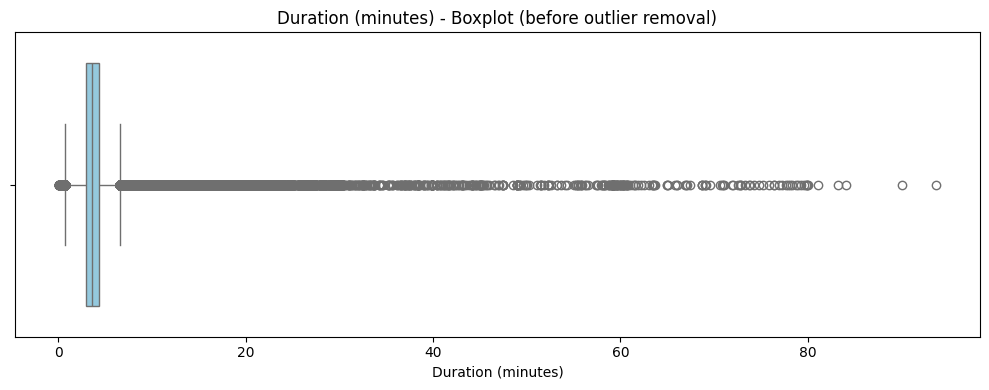


Outlier bounds (IQR method): [0.70, 6.62]
Dataset shape after outlier removal: (559486, 25)
Duration Statistics after outlier removal:
count    559486.000000
mean          3.576873
std           1.105014
min           0.698883
25%           2.892158
50%           3.528667
75%           4.270000
max           6.617117
Name: duration_minutes, dtype: float64


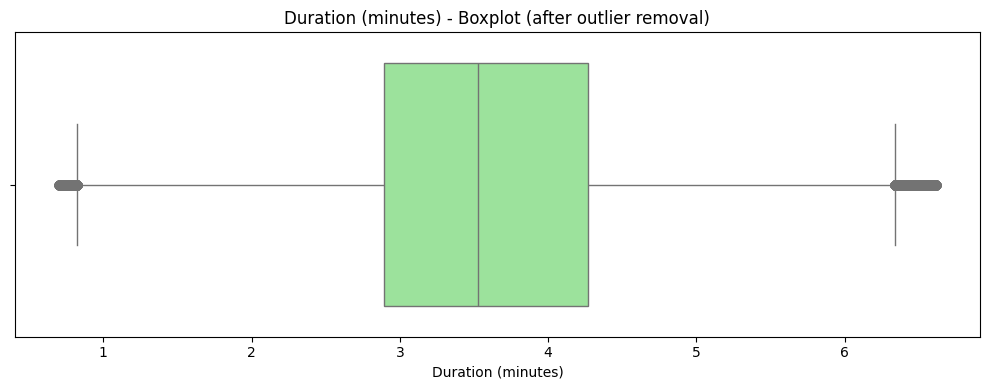

In [46]:
# Basic statistics for duration
print("Duration Statistics (in minutes):")
print(df_clean['duration_minutes'].describe())

# Remove outliers using boxplot (IQR method)
q1 = df_clean['duration_minutes'].quantile(0.25)
q3 = df_clean['duration_minutes'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['duration_minutes'], color='skyblue')
plt.title('Duration (minutes) - Boxplot (before outlier removal)')
plt.xlabel('Duration (minutes)')
plt.tight_layout()
plt.show()

df_clean = df_clean[(df_clean['duration_minutes'] >= lower_bound) & (df_clean['duration_minutes'] <= upper_bound)]

print(f"\nOutlier bounds (IQR method): [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Dataset shape after outlier removal: {df_clean.shape}")
print("Duration Statistics after outlier removal:")
print(df_clean['duration_minutes'].describe())

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['duration_minutes'], color='lightgreen')
plt.title('Duration (minutes) - Boxplot (after outlier removal)')
plt.xlabel('Duration (minutes)')
plt.tight_layout()
plt.show()

In [47]:
# Calculate average duration by decade (from 1940 to 2020)
df_1940 = df_clean[(df_clean['release_year'] >= 1940) & (df_clean['release_year'] <= 2029)].copy()

# Create decade column
df_1940['decade'] = (df_1940['release_year'] // 10 * 10).astype(str) + 's'

# Mean duration by decade
duration_by_decade = df_1940.groupby('decade')['duration_minutes'].mean().round(3).to_frame('mean_duration')

print("Average Duration by Decade (Mean, 1940s–2020s):")
print(duration_by_decade)

Average Duration by Decade (Mean, 1940s–2020s):
        mean_duration
decade               
1940s           3.100
1950s           3.151
1960s           3.114
1970s           3.500
1980s           3.597
1990s           3.816
2000s           3.892
2010s           3.686
2020s           3.266


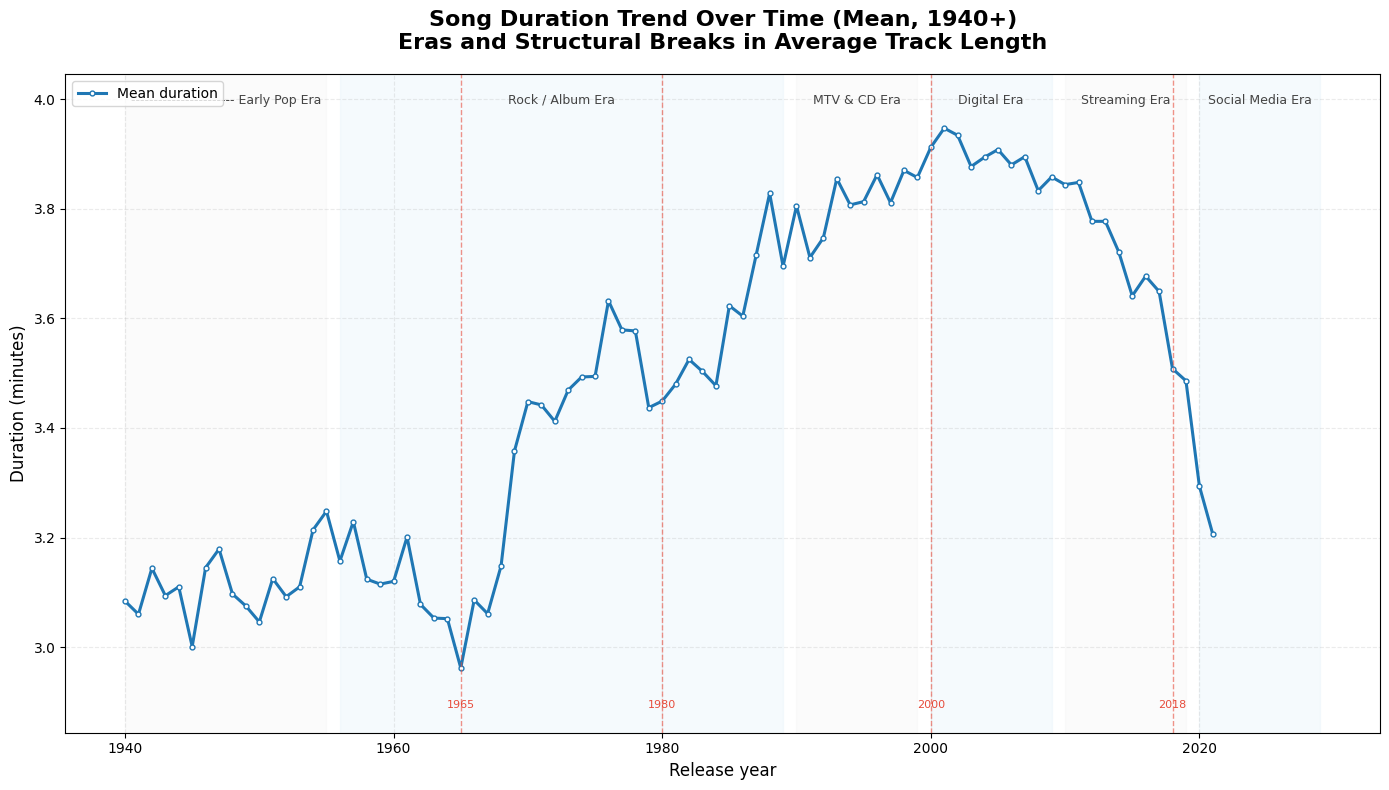

In [48]:
# Visualization 1: Duration trend over time (Mean only, from 1940) with eras highlighted
plt.figure(figsize=(14, 8))

# Filter from 1940 onwards
valid_years = duration_by_year.index[duration_by_year.index >= 1940]
mean_duration = duration_by_year.loc[valid_years, 'mean_duration']

# --- Main line + markers ------------------------------------------------------
plt.plot(
    valid_years,
    mean_duration,
    color="#1f77b4",
    linewidth=2.2,
    marker="o",
    markersize=3.5,
    markerfacecolor="white",
    markeredgecolor="#1f77b4",
    label="Mean duration"
)

# --- Define eras --------------------------------------------------------------
eras = [
    (1940, 1955, "----------------------- Early Pop Era"),
    (1956, 1989, "Rock / Album Era"),
    (1990, 1999, "MTV & CD Era"),
    (2000, 2009, "Digital Era"),
    (2010, 2019, "Streaming Era"),
    (2020, 2029, "Social Media Era"),
]

ymin, ymax = mean_duration.min(), mean_duration.max()

for i, (start, end, label) in enumerate(eras):
    # alternate soft background colors
    color = "#f5f5f5" if i % 2 == 0 else "#e8f4fa"
    plt.axvspan(start, end, color=color, alpha=0.4, zorder=0)

    # era label slightly above the plot area
    x_mid = (start + end) / 2
    plt.text(
        x_mid,
        ymax + (ymax - ymin) * 0.04,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        color="#444444"
    )

# --- Mark key change years ----------------------------------------------------
change_years = [1965, 1980, 2000, 2018]
for cy in change_years:
    if cy in valid_years:
        plt.axvline(cy, color="#e74c3c", linestyle="--", alpha=0.6, linewidth=1)
        plt.text(
            cy,
            ymin - (ymax - ymin) * 0.06,
            str(cy),
            color="#e74c3c",
            ha="center",
            va="top",
            fontsize=8
        )

# --- Titles, labels, style ----------------------------------------------------
plt.title(
    "Song Duration Trend Over Time (Mean, 1940+)\n"
    "Eras and Structural Breaks in Average Track Length",
    fontsize=16,
    fontweight="bold",
    pad=18
)
plt.xlabel("Release year", fontsize=12)
plt.ylabel("Duration (minutes)", fontsize=12)

plt.grid(True, alpha=0.25, linestyle="--")
plt.legend(frameon=True, fontsize=10, loc="upper left")

# add a bit of vertical margin so labels above/below are not cut
plt.ylim(ymin - (ymax - ymin) * 0.12, ymax + (ymax - ymin) * 0.10)

plt.tight_layout()
plt.show()

## Summary: The Evolution of Song Duration (1940–2024)
The analysis reveals that song duration has followed a non-linear path, deeply influenced by technological shifts and changing consumption habits:

## The Rise (1940–1990): 
Average track length grew steadily as the industry moved from short, radio-oriented singles (2–3 minutes) to longer, more complex compositions enabled by the LP record and later the CD. This trend peaked in the 1990s.

## The 1965 Turning Point: 
Despite the overall growth, the mid-1960s marked a local minimum. During this era, the 3-minute standard for hits remained dominant, making Dylan’s “Like a Rolling Stone” (over 6 minutes) a historic exception to the rule.

## The Modern Decline (2000–Present): 
With the advent of streaming and platforms like TikTok, the trend has drastically reversed. Average duration is now returning to 1940s levels, driven by algorithms that reward quick replays and shorter digital attention spans.

## Key Takeaway: 
Popular music first "expanded" with the rise of albums and CDs, only to "shrink" again in the digital era, effectively closing a century-long cycle.

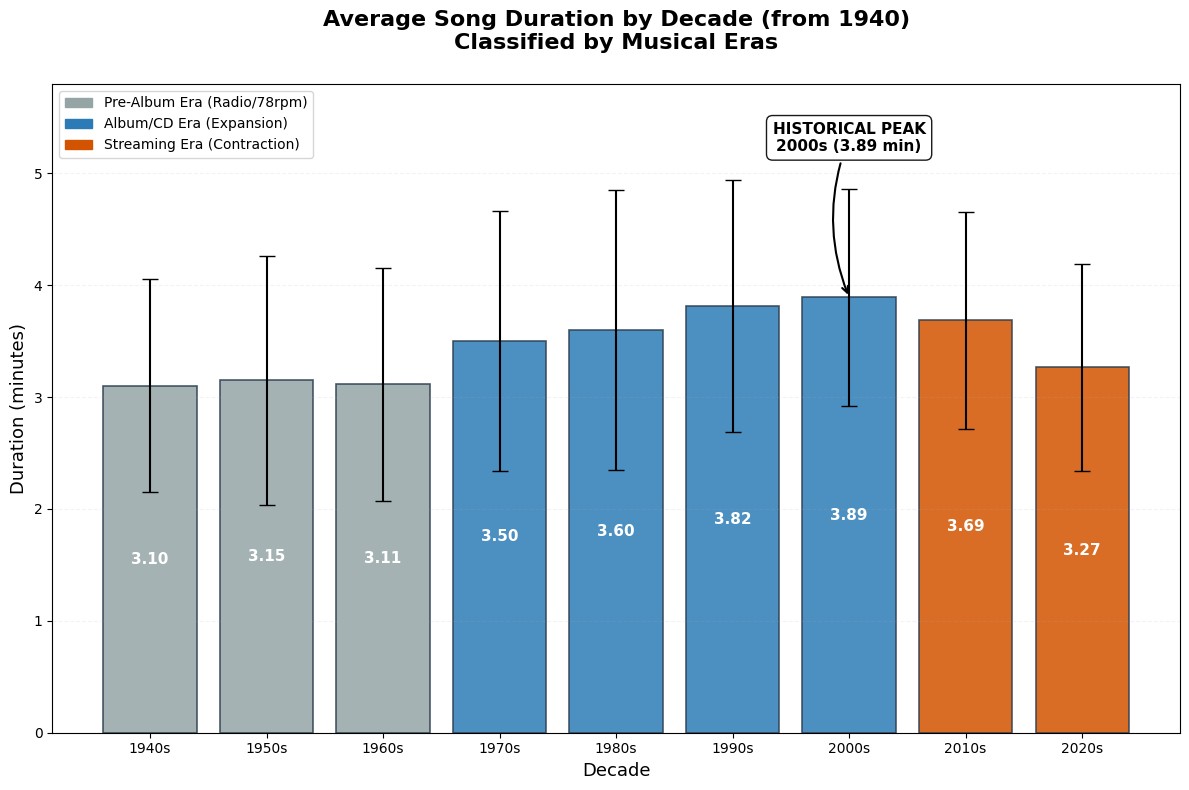

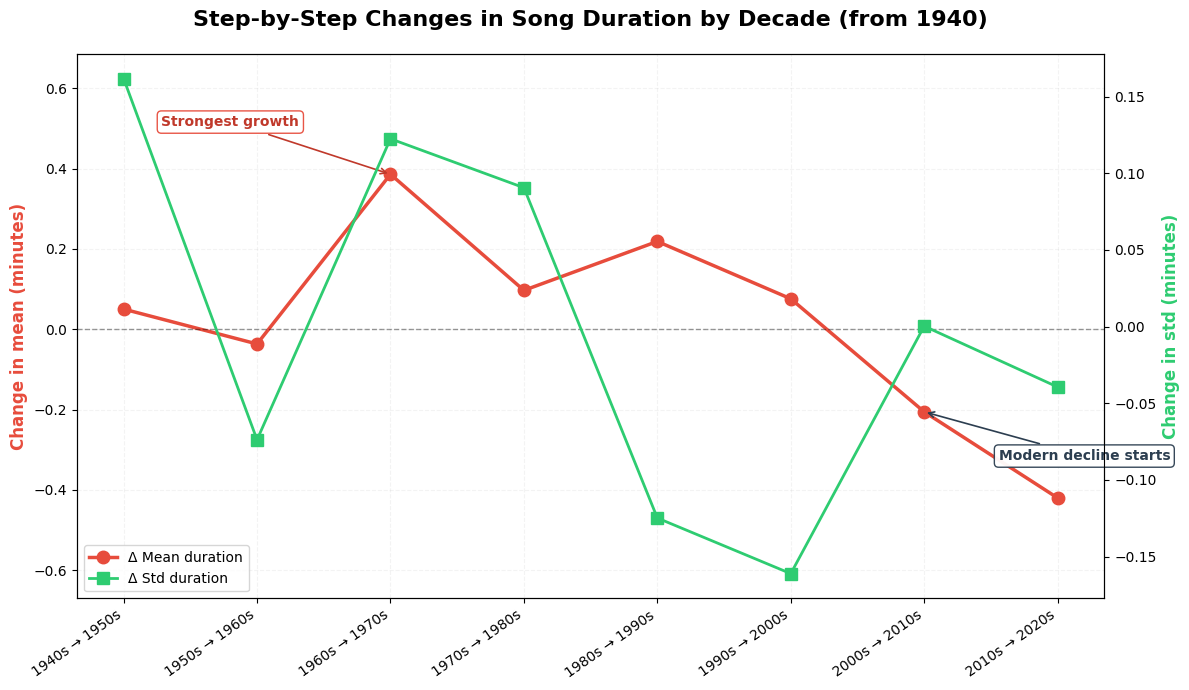

In [49]:
# --- Calcolo media e deviazione standard per decade (dal 1940) -----------------
df_1940 = df_clean[(df_clean['release_year'] >= 1940) & (df_clean['release_year'] <= 2029)].copy()
df_1940['decade'] = (df_1940['release_year'] // 10 * 10)

# Ordina le decadi
decades = sorted(df_1940['decade'].unique())
dec_labels = [f"{int(d)}s" for d in decades]

means = df_1940.groupby('decade')['duration_minutes'].mean().values
stds = df_1940.groupby('decade')['duration_minutes'].std().values

import matplotlib.patches as mpatches

# --- 1) Barplot: mean & std of duration by decade (from 1940) -----------------
fig, ax = plt.subplots(figsize=(12, 8))

era_colors = ["#95a5a6"]*3 + ["#2c7bb6"]*4 + ["#d35400"]*2

bars = ax.bar(
    dec_labels,
    means,
    yerr=stds,
    capsize=6,
    color=era_colors,
    alpha=0.85,
    edgecolor="#2c3e50",
    linewidth=1.2
)

# Numeri DENTRO le barre
for bar, m in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{m:.2f}",
        ha="center", va="center",
        fontsize=11, fontweight="bold", color="white"
    )

# Annotazione Peak Duration
peak_idx = means.argmax()
ax.annotate(
    f"HISTORICAL PEAK\n{dec_labels[peak_idx]} ({means[peak_idx]:.2f} min)",
    xy=(peak_idx, means[peak_idx]),
    xytext=(peak_idx, 5.2),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="arc3,rad=.2"),
    ha="center", fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9)
)

pre_patch = mpatches.Patch(color='#95a5a6', label='Pre-Album Era (Radio/78rpm)')
alb_patch = mpatches.Patch(color='#2c7bb6', label='Album/CD Era (Expansion)')
str_patch = mpatches.Patch(color='#d35400', label='Streaming Era (Contraction)')
ax.legend(handles=[pre_patch, alb_patch, str_patch], loc='upper left', fontsize=10, frameon=True)

ax.set_title("Average Song Duration by Decade (from 1940)\nClassified by Musical Eras",
             fontsize=16, fontweight="bold", pad=25)
ax.set_xlabel("Decade", fontsize=13)
ax.set_ylabel("Duration (minutes)", fontsize=13)
ax.set_ylim(0, 5.8)
ax.grid(axis="y", alpha=0.15, linestyle="--")
plt.tight_layout()
plt.show()

# --- 2) Line plot of changes between decades (delta mean & delta std) ---------
delta_means = means[1:] - means[:-1]
delta_stds  = stds[1:]  - stds[:-1]
transitions = [f"{int(decades[i])}s → {int(decades[i+1])}s" for i in range(len(decades) - 1)]

fig, ax1 = plt.subplots(figsize=(12, 7))
x = np.arange(len(transitions))

ax1.plot(x, delta_means, marker="o", markersize=9, color="#e74c3c",
         linewidth=2.5, label="Δ Mean duration")
ax2 = ax1.twinx()
ax2.plot(x, delta_stds, marker="s", markersize=9, color="#2ecc71",
         linewidth=2.0, label="Δ Std duration")

ax1.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
ax1.set_xticks(x)
ax1.set_xticklabels(transitions, rotation=35, ha="right", fontsize=10)
ax1.set_ylabel("Change in mean (minutes)", color="#e74c3c", fontsize=12, fontweight="bold")
ax2.set_ylabel("Change in std (minutes)", color="#2ecc71", fontsize=12, fontweight="bold")

# "Strongest growth": sopra il punto, con offset verticale positivo
max_inc_idx = np.argmax(delta_means)
ax1.annotate(
    "Strongest growth",
    xy=(max_inc_idx, delta_means[max_inc_idx]),
    xytext=(max_inc_idx - 1.2, delta_means[max_inc_idx] + 0.12),
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
    ha="center", fontsize=10, fontweight="bold", color="#c0392b",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e74c3c", alpha=0.95)
)

# "Modern decline starts": sotto il punto, con offset verticale negativo
decline_idx = np.where((np.array(decades[1:]) >= 2000) & (delta_means < 0))[0][0]
ax1.annotate(
    "Modern decline starts",
    xy=(decline_idx, delta_means[decline_idx]),
    xytext=(decline_idx + 1.2, delta_means[decline_idx] - 0.12),
    arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=1.2),
    ha="center", fontsize=10, fontweight="bold", color="#2c3e50",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#2c3e50", alpha=0.95)
)

ax1.set_title("Step‑by‑Step Changes in Song Duration by Decade (from 1940)",
              fontsize=16, fontweight="bold", pad=20)
ax1.set_ylim(min(delta_means) - 0.25, max(delta_means) + 0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", frameon=True, fontsize=10)

ax1.grid(True, alpha=0.15, linestyle="--")
plt.tight_layout()
plt.show()

#### Key Insights: Decadal Trends in Song Duration

The statistical analysis of song duration from 1940 onward shows a clear **expansion–contraction cycle**:

- **Peak Era (1970s–2000s):** The bar chart reveals a steady increase in average duration, peaking in the **1990s and 2000s** at close to 4 minutes per track.
- **Modern Contraction (2010s–2020s):** In the **2020s**, the average duration drops sharply, returning to values similar to the **1950s**, confirming the recent “shrinking song” phenomenon.
- **Speed of Change:** The step‑by‑step chart shows that the **2010s → 2020s** transition has the **steepest negative change** in mean duration in the whole series (more than 0.4 minutes).
- **Standardization:** The decline in standard deviation indicates that songs are not only shorter, but also **more similar in length**, suggesting stronger formatting pressures from streaming platforms and short‑form content.

**Overall, the data confirms that after decades of growth in the album and CD era, song length is now rapidly contracting in the streaming era.**

Duration by Popularity Category by Decade:
popularity_category       Low    Medium      High
decade                                           
1940                 3.090687  3.040859  3.431117
1950                 3.157813  3.186894  3.337348
1960                 3.106852  3.182028  3.134278
1970                 3.434944  3.723181  3.980596
1980                 3.566831  3.670628  4.203460
1990                 3.799134  3.839438  4.163998
2000                 3.832057  3.934278  3.890398
2010                 3.532457  3.745732  3.572947
2020                 3.400822  3.191532  3.224381


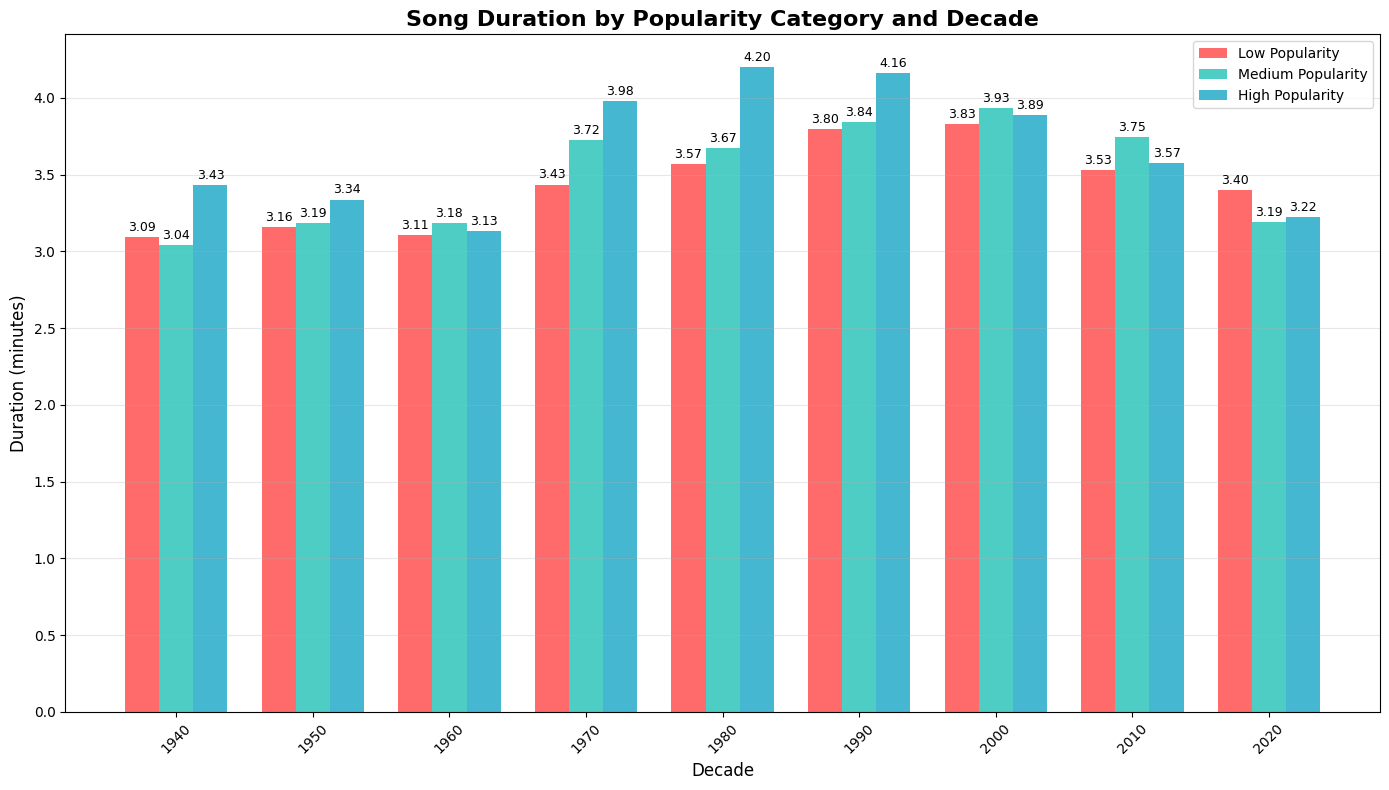

In [50]:
# Analysis by popularity level by decade
df_clean['popularity_category'] = pd.cut(df_clean['popularity'], 
                                        bins=[0, 33, 66, 100], 
                                        labels=['Low', 'Medium', 'High'])

# Add decade column
df_clean['decade'] = (df_clean['release_year'] // 10) * 10

# Calculate duration by popularity category and decade
duration_by_pop_decade = df_clean.groupby(['decade', 'popularity_category'])['duration_minutes'].mean().unstack()

# Filter decades with sufficient data
valid_decades = duration_by_pop_decade.index[duration_by_pop_decade.notna().all(axis=1)]
duration_by_pop_decade = duration_by_pop_decade.loc[valid_decades]

print("Duration by Popularity Category by Decade:")
print(duration_by_pop_decade.tail(10))

# Visualization: Duration trends by popularity category (Clustered Bar Chart)
plt.figure(figsize=(14, 8))

# Set up the plot
decades = duration_by_pop_decade.index
categories = duration_by_pop_decade.columns
x = np.arange(len(decades))
width = 0.25

# Create bars for each popularity category
bars1 = plt.bar(x - width, duration_by_pop_decade['Low'], width, label='Low Popularity', color='#FF6B6B')
bars2 = plt.bar(x, duration_by_pop_decade['Medium'], width, label='Medium Popularity', color='#4ECDC4')
bars3 = plt.bar(x + width, duration_by_pop_decade['High'], width, label='High Popularity', color='#45B7D1')

# Customize the plot
plt.title('Song Duration by Popularity Category and Decade', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.xticks(x, decades, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Song Duration by Popularity and Decade

This chart analyzes the relationship between **track duration** and **popularity levels** (Low, Medium, High) across decades.

- **The "Longer is Better" Era (1970s–1990s):** During these decades, there was a clear positive correlation between length and popularity. High-popularity songs (blue bars) were significantly longer than low-popularity ones, peaking in the **1980s** with an average of **4.20 minutes**.
- **The Shift in the 2000s:** In the 2000s, the gap began to close. While songs were still long (~3.9 min), the difference in duration between popularity categories started to vanish, signaling a transition in listener preferences.
- **The Streaming Reversal (2010s–2020s):** A major structural shift occurs in the most recent decades. In the **2020s**, the trend has completely reversed: **High-popularity songs (3.22 min) are now shorter than low-popularity songs (3.40 min).**
- **Efficiency over Complexity:** Modern hits are increasingly optimized for streaming. Shorter durations allow for higher replayability and better alignment with the fast-paced consumption patterns of platforms like TikTok and Spotify playlists.

**Conclusion: While being "longer" was once a hallmark of a hit song, today's most popular tracks are characterized by their brevity and efficiency.**

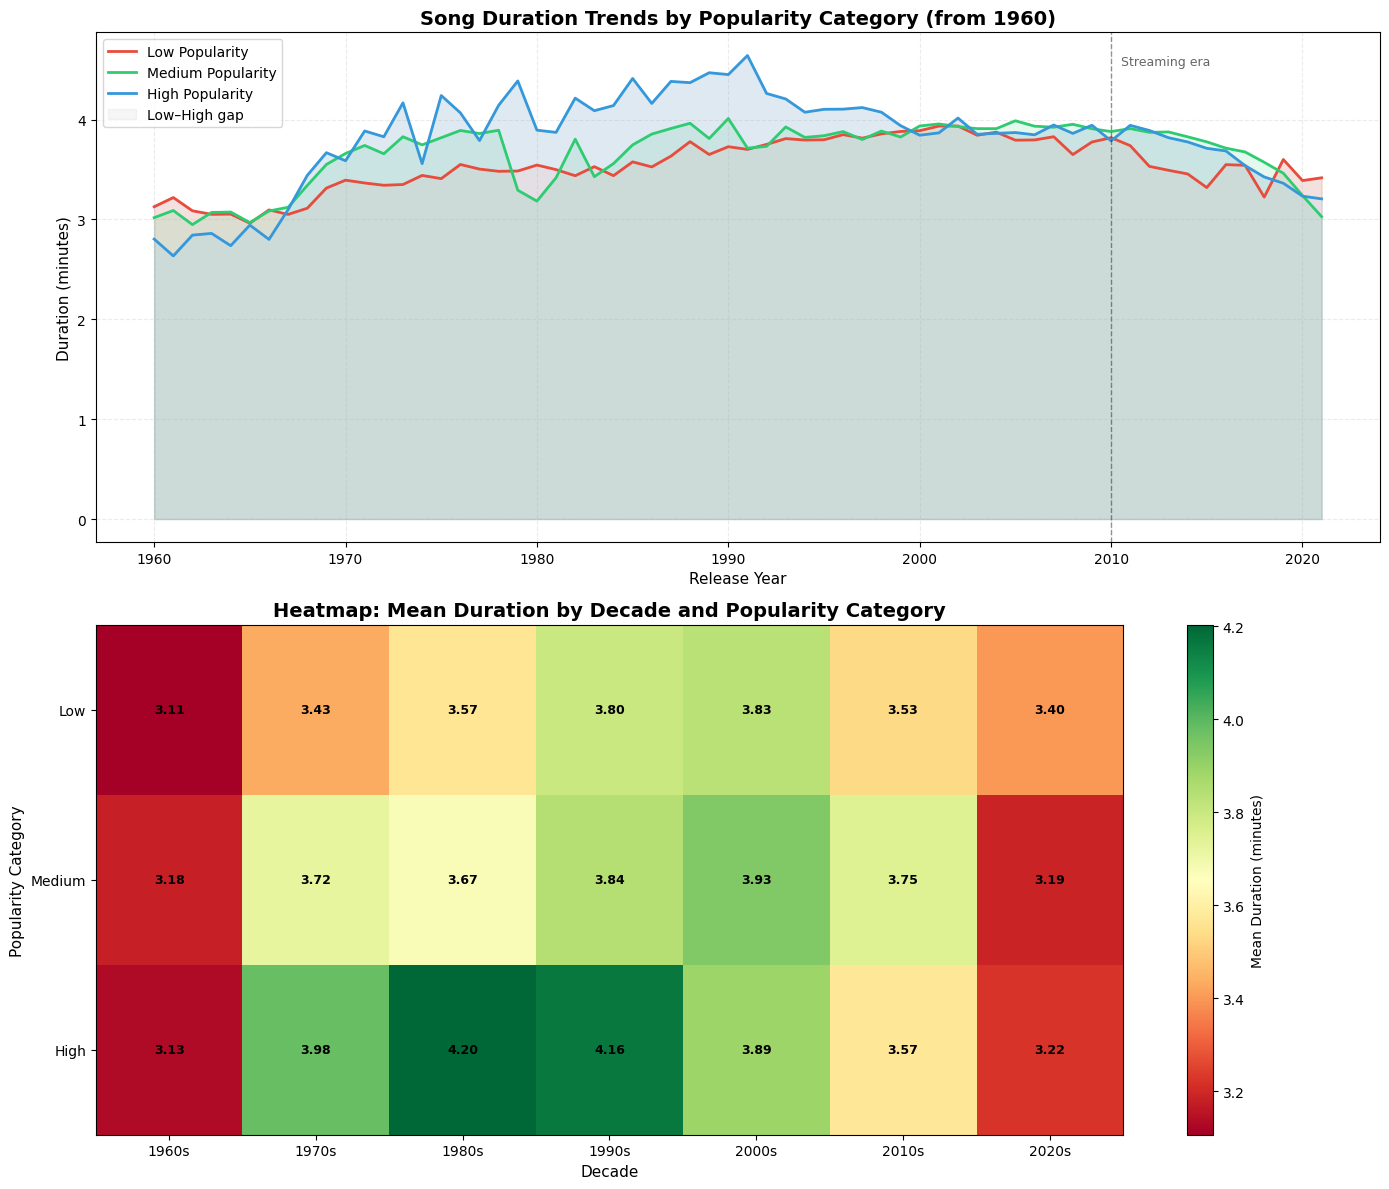

In [51]:
# Visualization 2 (alternative): Ribbon plot + Heatmap
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Data prep ----------------------------------------------------------------
df_1960_viz = df_clean[df_clean['release_year'] >= 1960].copy()

duration_by_pop_year = (
    df_1960_viz
    .groupby(['release_year', 'popularity_category'])['duration_minutes']
    .mean()
    .unstack()
)

colors = {
    'Low':    "#e74c3c",
    'Medium': "#2ecc71",
    'High':   "#3498db"
}

# --- Panel 1: Ribbon / filled area plot ---------------------------------------
ax1 = axes[0]

for category in ['Low', 'Medium', 'High']:
    if category in duration_by_pop_year.columns:
        y = duration_by_pop_year[category]
        x = duration_by_pop_year.index
        ax1.plot(x, y, linewidth=2, label=f'{category} Popularity',
                 color=colors[category])
        ax1.fill_between(x, y, alpha=0.12, color=colors[category])

# Shade the gap between Low and High to highlight divergence
if 'Low' in duration_by_pop_year.columns and 'High' in duration_by_pop_year.columns:
    ax1.fill_between(
        duration_by_pop_year.index,
        duration_by_pop_year['Low'],
        duration_by_pop_year['High'],
        alpha=0.07, color="gray", label="Low–High gap"
    )

ax1.axvline(2010, color="black", linestyle="--", alpha=0.4, linewidth=1)
ax1.text(2010.5, duration_by_pop_year.max().max() * 0.98,
         "Streaming era", fontsize=9, color="black", alpha=0.6)

ax1.set_title("Song Duration Trends by Popularity Category (from 1960)",
              fontsize=14, fontweight="bold")
ax1.set_xlabel("Release Year", fontsize=11)
ax1.set_ylabel("Duration (minutes)", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25, linestyle="--")

# --- Panel 2: Heatmap of mean duration (decade × popularity) ------------------
ax2 = axes[1]

df_1960_viz['decade'] = (df_1960_viz['release_year'] // 10) * 10
heatmap_data = (
    df_1960_viz
    .groupby(['decade', 'popularity_category'])['duration_minutes']
    .mean()
    .unstack()
    [['Low', 'Medium', 'High']]
    .T
)

im = ax2.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn')

ax2.set_xticks(range(len(heatmap_data.columns)))
ax2.set_xticklabels([f"{int(d)}s" for d in heatmap_data.columns], fontsize=10)
ax2.set_yticks(range(len(heatmap_data.index)))
ax2.set_yticklabels(heatmap_data.index, fontsize=10)

# Annotate cells with values
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f"{val:.2f}", ha='center', va='center',
                     fontsize=9, color='black', fontweight='bold')

plt.colorbar(im, ax=ax2, label="Mean Duration (minutes)")
ax2.set_title("Heatmap: Mean Duration by Decade and Popularity Category",
              fontsize=14, fontweight="bold")
ax2.set_xlabel("Decade", fontsize=11)
ax2.set_ylabel("Popularity Category", fontsize=11)

plt.tight_layout()
plt.show()

#### Song Duration and Popularity: Long‑term Trends and Decadal Patterns

The figure combines two complementary views to explore how **song duration** interacts with **popularity** from 1960 onwards.

**Top panel – Ribbon plot (yearly trends)**  
- From the 1960s to the early 2000s, all three categories (Low, Medium, High popularity) show a **joint upward trend** in duration, with highly popular tracks consistently sitting at the top of the range.  
- The shaded area between the Low and High lines (“Low–High gap”) is widest in the **1980s–1990s**, indicating that hit songs were not only longer on average, but also clearly longer than less popular tracks.  
- After ~2010 (marked as the start of the streaming era), all curves bend downwards and begin to **converge**, suggesting that popularity is no longer associated with significantly longer tracks.

**Bottom panel – Heatmap (decade × popularity)**  
- The heatmap confirms a **peak in duration** for High‑popularity songs in the **1980s (4.20 min)** and a gradual decline afterwards.  
- By the **2020s**, the difference between popularity categories almost disappears: High‑popularity songs (3.22 min) are only marginally longer than Low‑popularity ones (3.40 min), and both are much shorter than in previous decades.  
- The color gradient highlights a clear shift from **longer, differentiated durations** (green tones in the 1980s–1990s) to **shorter, more homogeneous lengths** (yellow–orange in the 2010s–2020s).

**Takeaway:** Historically, being a “hit” was associated with **longer songs**, especially during the album and CD era. In the streaming era, that relationship weakens: the most popular tracks are now **short, tightly formatted**, and much closer in length to less popular songs.

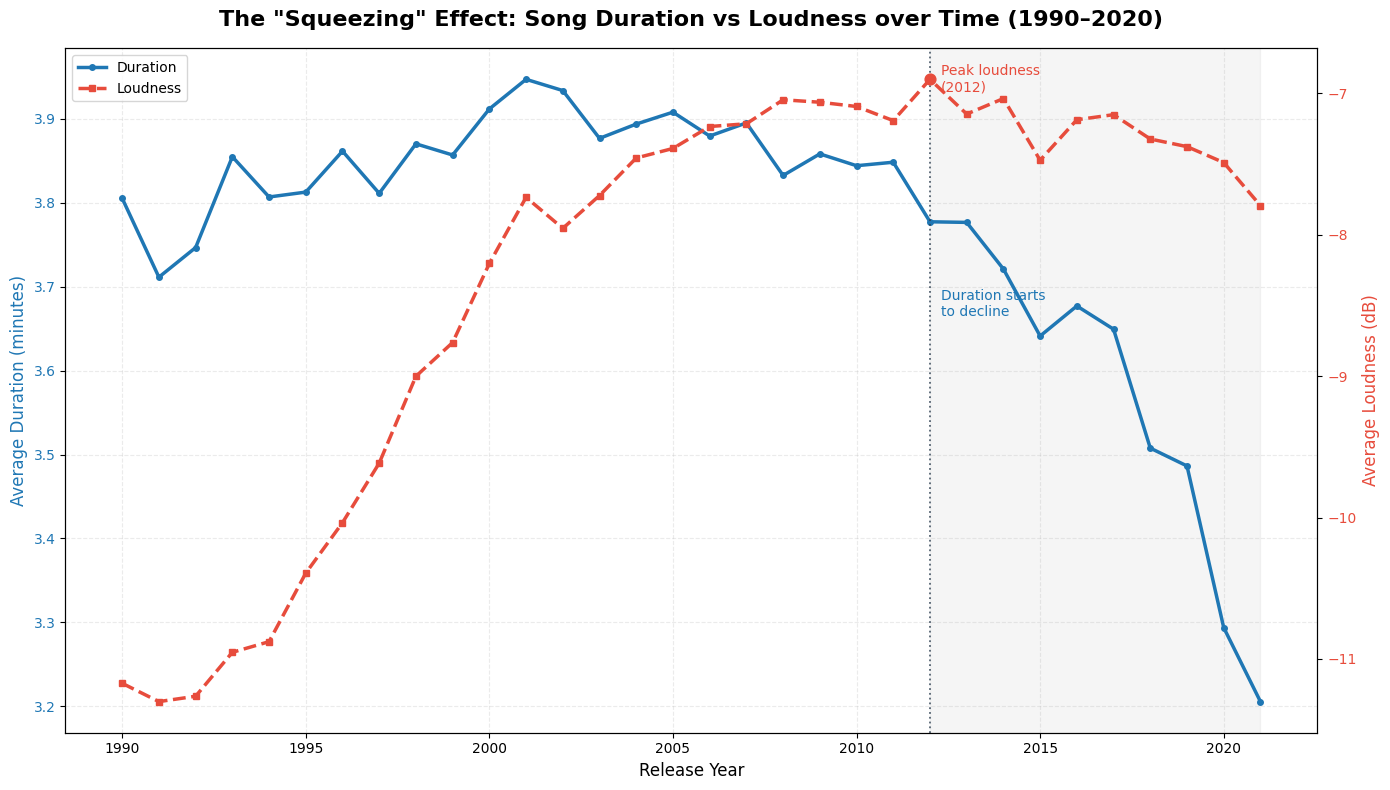

In [52]:
# 1. Prepare the data: mean per year (from 1990)
yearly_trends = (
    df_clean[df_clean['year'] >= 1990]
    .groupby('year')[['duration_ms', 'loudness']]
    .mean()
    .reset_index()
)

yearly_trends['duration_min'] = yearly_trends['duration_ms'] / 60000

years = yearly_trends['year']
dur   = yearly_trends['duration_min']
loud  = yearly_trends['loudness']

# Find peak loudness year
peak_loud_idx = loud.idxmax()
peak_loud_year = int(years[peak_loud_idx])
peak_loud_val  = loud[peak_loud_idx]

# 2. Create the plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Axis 1: Duration
color1 = "#1f77b4"
ax1.set_xlabel("Release Year", fontsize=12)
ax1.set_ylabel("Average Duration (minutes)", color=color1, fontsize=12)
ax1.plot(years, dur, color=color1, linewidth=2.5,
         marker="o", markersize=4, label="Duration")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.25, linestyle="--")

# Axis 2: Loudness
ax2 = ax1.twinx()
color2 = "#e74c3c"
ax2.set_ylabel("Average Loudness (dB)", color=color2, fontsize=12)
ax2.plot(years, loud, color=color2, linewidth=2.5,
         linestyle="--", marker="s", markersize=4, label="Loudness")
ax2.tick_params(axis="y", labelcolor=color2)

# Highlight period after peak loudness
ax1.axvspan(peak_loud_year, years.max(), color="gray", alpha=0.08)

# Vertical line at peak loudness
ax1.axvline(peak_loud_year, color="#2c3e50", linestyle=":", linewidth=1.3, alpha=0.8)

# Annotations
ax2.scatter(peak_loud_year, peak_loud_val, color=color2, s=60, zorder=5)
ax2.text(
    peak_loud_year + 0.3, peak_loud_val,
    f"Peak loudness\n({peak_loud_year})",
    color=color2, fontsize=10, va="center", ha="left"
)

# approximate duration at that year
peak_dur_val = dur[years == peak_loud_year].iloc[0]
ax1.text(
    peak_loud_year + 0.3, peak_dur_val - 0.08,
    "Duration starts\nto decline",
    color=color1, fontsize=10, va="top", ha="left"
)

plt.title(
    'The "Squeezing" Effect: Song Duration vs Loudness over Time (1990–2020)',
    fontsize=16, fontweight="bold", pad=16
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", frameon=True)

fig.tight_layout()
plt.show()

#### The “squeezing” effect: when maximum loudness meets shrinking duration

This chart tracks the evolution of **average song duration** (blue, left axis) and **average loudness** (red, right axis) from 1990 to 2020.

- From the early 1990s up to the **late 2000s**, both curves rise together: songs become **longer and louder** at the same time.
- Around **the year of peak loudness** (vertical dotted line), loudness levels reach their maximum while duration is close to its historical high.
- **After this peak**, loudness stabilizes and then slightly decreases, while **average duration clearly starts to fall**, marking the onset of the modern “short song” era.
- The shaded region to the right of the peak highlights this phase where the catalogue remains very loud, but tracks are progressively **compressed in length**.

In summary, the data suggest a temporal link: once loudness stopped increasing, the industry’s next lever of optimization became **song length**, leading to shorter but still very loud tracks.

### **Project Summary: The Evolution of Spotify Global Charts (1940–2024)**

#### **1. The Historical Cycle of Song Duration**
The analysis reveals a **U-shaped trend**: song length grew during the Vinyl/CD eras (1960–2000), peaking at nearly **4 minutes**, but has since collapsed. We are now returning to the brevity of the 1950s.

#### **2. The "Squeezing" Effect: Loudness vs. Length**
There is a clear structural shift around **2010–2012**. Once the "Loudness War" reached its peak volume, the industry shifted its strategy: instead of getting louder, songs began to **shrink in duration** to maximize streaming replays.

#### **3. The New "Hit" Formula**
*   **Past (1980s):** High-popularity songs were significantly **longer** (avg. 4.20 min).
*   **Present (2020s):** High-popularity songs are now **shorter** than average (avg. 3.22 min).
*   **Top 10 Evidence:** Tracks in the Top 10 are consistently shorter than the rest of the charts, confirming that brevity is now a competitive advantage.

#### **4. Statistical Significance**
The decline is not accidental. Comparing 2005–2014 (3.84 min) to 2015–2021 (3.32 min) shows a **statistically significant drop** ($p < 0.001$) with a large effect size (Cohen's $d = -0.819$). The most aggressive decline has occurred since 2015 ($-0.115$ min/year).

#### **Final Conclusion**
We have entered the era of **"Compressed Music."** Driven by streaming algorithms and TikTok, the industry has traded complexity and length for **efficiency and replayability**, effectively closing a century-long cycle of musical expansion.